Success: Loaded filtered 2021 data from charts_2021_filtered.csv

MULTIPLE REGRESSION RESULTS (ALL AUDIO FEATURES)
                            OLS Regression Results                            
Dep. Variable:          Migration_Lag   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     7854.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:50:05   Log-Likelihood:            -1.6738e+07
No. Observations:             3060943   AIC:                         3.348e+07
Df Residuals:                 3060934   BIC:                         3.348e+07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------

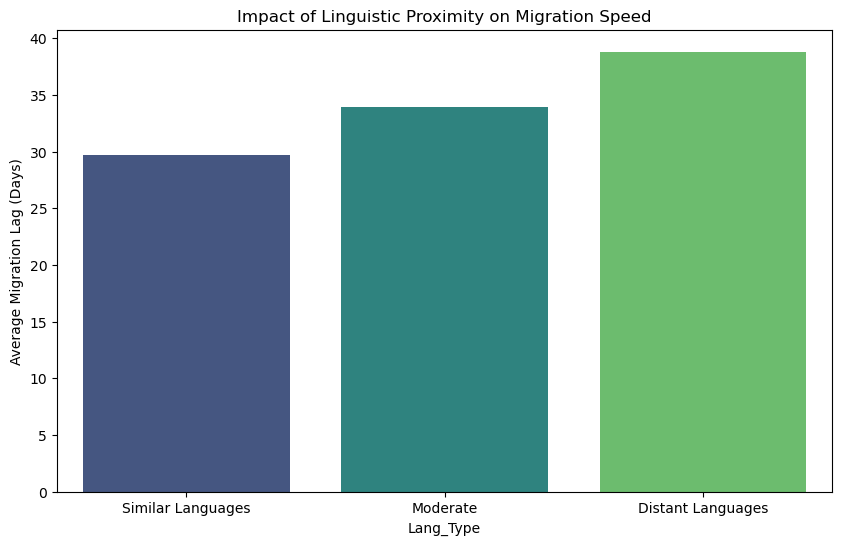

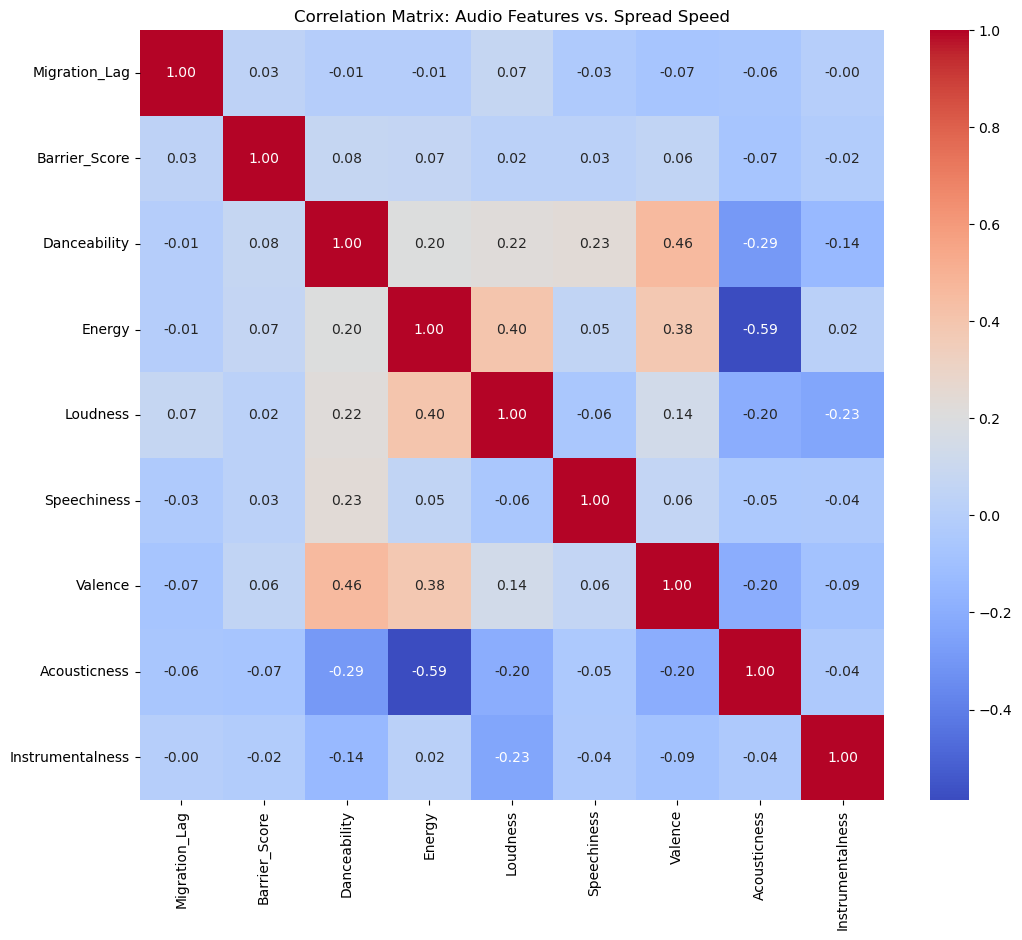


CASE STUDY: TURKEY (TUR) SPREAD ANALYSIS
Top 10 Destinations for Turkish Music (Speed):
Region_ISO3
AUT    1.0
DEU    1.0
WLD    1.0
Name: Migration_Lag, dtype: float64

REGIONAL SCENARIO COMPARISON TABLE
       Scenario  Avg Lag (Days)  Avg Energy        Mechanism
  Latin Highway       26.764098    0.646985       Linguistic
  K-Pop Paradox      109.598958    0.738378  Technical/Audio
    Nordic Sync        6.027128    0.745750 Digital/Cultural
Anglo-Influence       33.759620    0.599392 Global Dominance


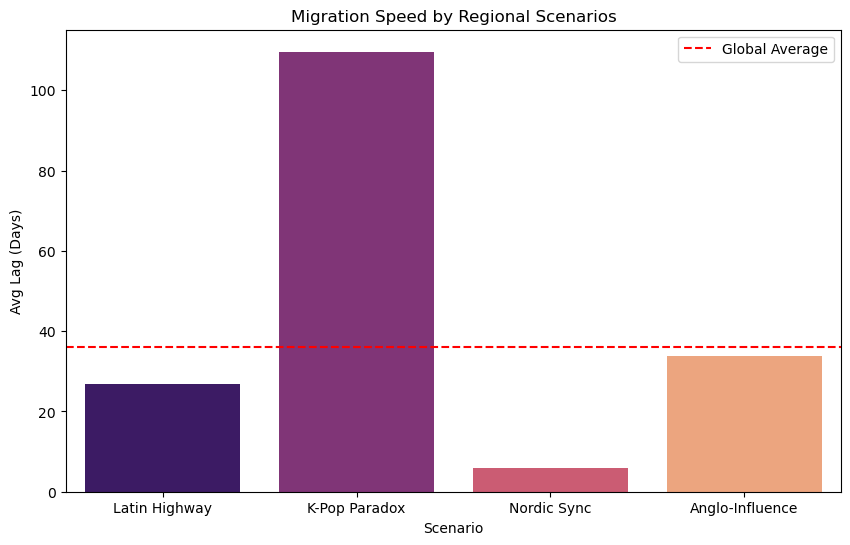


SUMMARY STATISTICS
Avg Lag (Similar Languages): 29.71 days
Avg Lag (Distant Languages): 38.82 days
Analysis Complete.


In [1]:
#Asıl olan
import pandas as pd
import numpy as np
import pycountry
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETTINGS AND FILE LOADING
CHART_FILE = 'charts.csv'
AUDIO_FILE = 'Spotify_Dataset_V3.csv'
LING_FILE = 'ling_web (1).dta'
FILTERED_OUTPUT = 'charts_2021_filtered.csv'

CHART_COLS = ['title', 'artist', 'date', 'region']

# --- STEP A: LOAD OR CREATE 2021 FILTERED DATA ---
try:
    charts_df = pd.read_csv(FILTERED_OUTPUT)
    charts_df['date'] = pd.to_datetime(charts_df['date'])
    print(f"Success: Loaded filtered 2021 data from {FILTERED_OUTPUT}")
except FileNotFoundError:
    print("Processing charts.csv to extract 2021 data. This may take a few minutes...")
    chunks = pd.read_csv(CHART_FILE, chunksize=250000, usecols=CHART_COLS)
    filtered_list = [chunk[pd.to_datetime(chunk['date'], errors='coerce').dt.year == 2021] for chunk in chunks]
    charts_df = pd.concat(filtered_list)
    charts_df.to_csv(FILTERED_OUTPUT, index=False)
    print("Filter complete. Saved as charts_2021_filtered.csv")

audio_df = pd.read_csv(AUDIO_FILE, sep=';')
ling_df = pd.read_stata(LING_FILE)

# --- STEP B: STANDARDIZATION AND CLEANING ---

def country_to_iso3(name):
    if pd.isna(name): return None
    name_clean = str(name).strip()
    try:
        # Try library lookup first
        return pycountry.countries.lookup(name_clean).alpha_3
    except:
        # Manual mapping for edge cases and re-branding
        manual_map = {
            'Turkey': 'TUR', 'Türkiye': 'TUR', 'United States': 'USA', 
            'United Kingdom': 'GBR', 'South Korea': 'KOR', 'Global': 'WLD',
            'USA': 'USA', 'UK': 'GBR', 'Russia': 'RUS', 'Vietnam': 'VNM'
        }
        return manual_map.get(name_clean, None)

# Apply country codes
audio_df['Artist_ISO3'] = audio_df['Nationality'].apply(country_to_iso3)
charts_df['Region_ISO3'] = charts_df['region'].apply(country_to_iso3)

# Text Normalization for matching
charts_df['title'] = charts_df['title'].astype(str).str.lower().str.strip()
charts_df['artist'] = charts_df['artist'].astype(str).str.lower().str.strip()
audio_df['Title'] = audio_df['Title'].astype(str).str.lower().str.strip()
audio_df['Artists'] = audio_df['Artists'].astype(str).str.lower().str.strip()

# --- STEP C: MIGRATION LAG AND DATA MERGING ---

# Find earliest appearance of each song in each region
first_appearances = charts_df.groupby(['title', 'artist', 'Region_ISO3'])['date'].min().reset_index()

# Merge with Audio Features
migration_df = pd.merge(
    first_appearances, 
    audio_df[['Title', 'Artists', 'Artist_ISO3', 'Danceability', 'Energy', 
              'Loudness', 'Speechiness', 'Valence', 'Acousticness', 'Instrumentalness']], 
    left_on=['title', 'artist'], 
    right_on=['Title', 'Artists']
)

# Identify Home Market Debut
home_market = migration_df[migration_df['Region_ISO3'] == migration_df['Artist_ISO3']]
home_start_dates = home_market.groupby(['title', 'artist'])['date'].min().reset_index().rename(columns={'date': 'Home_Start_Date'})

# Calculate Migration Lag
final_analysis = pd.merge(migration_df, home_start_dates, on=['title', 'artist'])
final_analysis['Migration_Lag'] = (final_analysis['date'] - final_analysis['Home_Start_Date']).dt.days
analysis_df = final_analysis[final_analysis['Migration_Lag'] > 0].copy()

# Add Linguistic Barrier Score
analysis_df = pd.merge(analysis_df, ling_df, left_on=['Artist_ISO3', 'Region_ISO3'], right_on=['iso_o', 'iso_d'], how='left')
analysis_df[['lp1', 'csl']] = analysis_df[['lp1', 'csl']].fillna(0)
analysis_df['Barrier_Score'] = 1 - (analysis_df['csl'] * analysis_df['lp1'])

# --- STEP D: ANALYSIS AND VISUALIZATION ---

# 1. Linguistic Proximity Groups
def lang_group(score):
    if score <= 0.2: return 'Similar Languages'
    elif score >= 0.8: return 'Distant Languages'
    else: return 'Moderate'

analysis_df['Lang_Type'] = analysis_df['Barrier_Score'].apply(lang_group)
speed_by_lang = analysis_df.groupby('Lang_Type')['Migration_Lag'].mean().sort_values()

# 2. Multiple Regression Analysis (Hypothesis Testing)
print("\n" + "="*50)
print("MULTIPLE REGRESSION RESULTS (ALL AUDIO FEATURES)")
print("="*50)
features = ['Barrier_Score', 'Danceability', 'Energy', 'Loudness', 
            'Speechiness', 'Valence', 'Acousticness', 'Instrumentalness']
X = sm.add_constant(analysis_df[features])
y = analysis_df['Migration_Lag']
model = sm.OLS(y, X).fit()
print(model.summary())

# 3. Plot: Linguistic Proximity vs Migration Lag
plt.figure(figsize=(10, 6))
sns.barplot(x=speed_by_lang.index, y=speed_by_lang.values, hue=speed_by_lang.index, palette='viridis', legend=False)
plt.title('Impact of Linguistic Proximity on Migration Speed')
plt.ylabel('Average Migration Lag (Days)')
plt.show()

# 4. Plot: Extended Correlation Heatmap
plt.figure(figsize=(12, 10))
cols_to_corr = ['Migration_Lag', 'Barrier_Score'] + features[1:]
sns.heatmap(analysis_df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Audio Features vs. Spread Speed')
plt.show()

# 5. Case Study: Turkey (TUR) Analysis
tr_songs = analysis_df[analysis_df['Artist_ISO3'] == 'TUR']
print("\n" + "="*50)
print("CASE STUDY: TURKEY (TUR) SPREAD ANALYSIS")
print("="*50)
if tr_songs.empty:
    print("Notice: No TUR songs found. This might be due to limited international entries in 2021.")
else:
    tr_spread = tr_songs.groupby('Region_ISO3')['Migration_Lag'].mean().sort_values()
    print("Top 10 Destinations for Turkish Music (Speed):")
    print(tr_spread.head(10))

# --- STEP E: REGIONAL PERSPECTIVES (SCENARIO ANALYSIS) ---

scenarios = {
    'Latin Highway': {'source': 'ESP', 'dest': ['MEX', 'COL', 'ARG'], 'type': 'Linguistic'},
    'K-Pop Paradox': {'source': 'KOR', 'dest': ['THA', 'VNM', 'PHL'], 'type': 'Technical/Audio'},
    'Nordic Sync': {'source': 'SWE', 'dest': ['NOR', 'DNK', 'FIN'], 'type': 'Digital/Cultural'},
    'Anglo-Influence': {'source': 'USA', 'dest': ['TUR', 'JPN', 'BRA'], 'type': 'Global Dominance'}
}

regional_data = []
for name, info in scenarios.items():
    subset = analysis_df[(analysis_df['Artist_ISO3'] == info['source']) & 
                         (analysis_df['Region_ISO3'].isin(info['dest']))]
    if not subset.empty:
        regional_data.append({
            'Scenario': name,
            'Avg Lag (Days)': subset['Migration_Lag'].mean(),
            'Avg Energy': subset['Energy'].mean(),
            'Mechanism': info['type']
        })

regional_df = pd.DataFrame(regional_data)
print("\n" + "="*50)
print("REGIONAL SCENARIO COMPARISON TABLE")
print("="*50)
print(regional_df.to_string(index=False))

# Plot: Scenario Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Scenario', y='Avg Lag (Days)', data=regional_df, hue='Scenario', palette='magma', legend=False)
plt.axhline(analysis_df['Migration_Lag'].mean(), color='red', linestyle='--', label='Global Average')
plt.title('Migration Speed by Regional Scenarios')
plt.legend()
plt.show()

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Avg Lag (Similar Languages): {speed_by_lang.get('Similar Languages', 0):.2f} days")
print(f"Avg Lag (Distant Languages): {speed_by_lang.get('Distant Languages', 0):.2f} days")
print("Analysis Complete.")